# Geological Modeling with GemPy - Tharsis AOI 1

This notebook demonstrates 3D geological modeling using GemPy for the Tharsis Area of Interest 1. The workflow includes data preprocessing, model creation, and visualization of geological structures.

## 1. Import Required Libraries and Setup Configuration

Import necessary libraries for geological modeling, data processing, and visualization.

In [41]:
import os
import threading
import gempy as gp
import pandas as pd
import HelperMethods
import gempy_viewer as gpv
import numpy as np
import matplotlib.pyplot as plt

# Setup base directory
BASE_DIR = os.getcwd()
print(f"Base directory: {BASE_DIR}")

Base directory: c:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\GeoModel


## 2. Define File Paths and Model Parameters

Set up all file paths for input data and define model configuration parameters.

In [2]:
# Define data directory and file paths
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

path_to_data = os.path.join(data_dir, 'formationinputpoints_reduced.csv')
path_to_orientations = os.path.join(data_dir, 'orientations_reduced.csv')
path_to_topography = os.path.join(data_dir, 'topo.tif')
path_to_topography_cleaned = os.path.join(data_dir, 'topo_cleaned.tif')
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced.tif')

# Model parameters
invalid_below = -100  # Define what we consider invalid topography
model_depth = -500  # Define the depth of the model
topo_reduction_factor = 0.1  # Define the factor by which to reduce the topography resolution

# Processing triggers
trigger_create_cross_section = True  # Set to True if you want to create a cross section
trigger_drop_lithologies = False  # Set to True if you want to drop certain lithologies

# Lithologies to optionally drop
lithologies_to_drop = [
    "Upper Carboniferous Volcanics",
    "Tournaisian Plutonites"
]

print("File paths and parameters configured successfully!")

File paths and parameters configured successfully!


## 3. Load and Examine Input Data

Load CSV files containing formation points and orientation data, then examine the data structure and calculate bounding box coordinates.

In [3]:
# Load geological data
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')
orientations_df = pd.read_csv(path_to_orientations, encoding='latin1', engine='python')

print("Data loaded successfully!")
print(f"Formation points shape: {points_df.shape}")
print(f"Orientations shape: {orientations_df.shape}")

# Display first few rows
print("\nFormation points (first 5 rows):")
display(points_df.head())

print("\nOrientations (first 5 rows):")
display(orientations_df.head())

Data loaded successfully!
Formation points shape: (4, 5)
Orientations shape: (7, 8)

Formation points (first 5 rows):


,X,Y,Z,formation,formation_id
0,-697098,4543927,271,Upper Devonian Siliciclastics,40
1,-705656,4548904,357,Mid Carboniferous Shales,76
2,-700314,4545329,346,Upper Devonian Siliciclastics,40
3,-704835,4530651,344,Visean Shales,67



Orientations (first 5 rows):


,X,Y,Z,azimuth,dip,polarity,formation,formation_id
0,-697098,4543927,271,284,55,-1,Upper Devonian Siliciclastics,40
1,-681850,4530352,161,286,47,-1,Upper Devonian Siliciclastics,40
2,-681855,4530372,286,318,30,-1,Upper Devonian Siliciclastics,40
3,-705656,4548904,357,134,38,-1,Mid Carboniferous Shales,76
4,-704549,4547233,500,105,30,-1,Upper Devonian Siliciclastics,40


In [4]:
# Define coordinate bounds from the data
top_right = (-678192, 4549947)
bottom_right = (-677518, 4529455)
bottom_left = (-706792, 4528453)
top_left = (-707522, 4548927)


# Calculate bounding box of the area of interest
min_x = min(top_left[0], bottom_left[0])
max_x = max(top_right[0], bottom_right[0])
min_y = min(bottom_left[1], bottom_right[1])
max_y = max(top_left[1], top_right[1])
max_z = points_df['Z'].max()

print(f"Bounding box calculated:")
print(f"X range: {min_x} to {max_x}")
print(f"Y range: {min_y} to {max_y}")
print(f"Z range: {model_depth} to {max_z}")

Bounding box calculated:
X range: -707522 to -677518
Y range: 4528453 to 4549947
Z range: -500 to 357


## 4. Clean and Preprocess Topography Data

Process the topography data by cleaning invalid values and reducing resolution for computational efficiency.

In [5]:
# Clean topography file
print("Cleaning topography file...")
HelperMethods.clean_topo_file(path_to_topography, path_to_topography_cleaned)

# Reduce topography resolution
print(f"Reducing topography resolution by factor {topo_reduction_factor}...")
HelperMethods.reduce_tif_resolution(
    input_path=path_to_topography_cleaned,
    output_path=path_to_topography_reduced,
    scale_factor=topo_reduction_factor
)

# Update path with scale factor suffix
base, ext = os.path.splitext(path_to_topography_reduced)
path_to_topography_reduced = f"{base}_sf{topo_reduction_factor}{ext}"

print(f"Processed topography saved to: {path_to_topography_reduced}")

Cleaning topography file...
Reducing topography resolution by factor 0.1...
Processed topography saved to: c:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\GeoModel\..\Data\Tharsis AOI 1\topo_reduced_sf0.1.tif


## 5. Filter Lithologies (Optional)

Optionally remove specified lithologies from the dataset based on trigger settings.

In [6]:
# Conditionally drop lithologies
if trigger_drop_lithologies:
    print("Dropping specified lithologies...")
    print(f"Lithologies to drop: {lithologies_to_drop}")
    HelperMethods.drop_lithologies(points_df, orientations_df, lithologies_to_drop)
    print("Lithologies dropped successfully!")
else:
    print("Lithology filtering is disabled - keeping all lithologies")

Lithology filtering is disabled - keeping all lithologies


## 6. Create GemPy Geological Model

Initialize the geological model using GemPy with specified extent, refinement, and input data.

In [7]:
# Create the geological model
print("Creating GemPy geological model...")

geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
    refinement=6,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=os.path.join(BASE_DIR, "temp_orientations.csv"),
        path_to_surface_points=os.path.join(BASE_DIR, "temp_points.csv"),
    )
)

# geo_model = gp.create_geomodel(
#     project_name='AOI',
#     extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
#     refinement=6,
#     importer_helper=gp.data.ImporterHelper(
#         path_to_orientations='sampled_orientationinputpoints.csv',
#         path_to_surface_points='sampled_formationinputpoints.csv',
#     )
# )

print("Geological model created successfully!")

Creating GemPy geological model...
Geological model created successfully!


In [8]:
geo_model.grid # 64 x 64 x 64 voxels

Grid(values=array([[-7.07287594e+05,  4.54977908e+06, -4.93304688e+02],
       [-7.07287594e+05,  4.54977908e+06, -4.79914062e+02],
       [-7.07287594e+05,  4.54977908e+06, -4.66523438e+02],
       ...,
       [-6.77752406e+05,  4.52862092e+06,  3.23523438e+02],
       [-6.77752406e+05,  4.52862092e+06,  3.36914062e+02],
       [-6.77752406e+05,  4.52862092e+06,  3.50304688e+02]]), length=array([], dtype=float64), _octree_grid=RegularGrid(resolution=array([64, 64, 64]), extent=array([-7.075220e+05, -6.775180e+05,  4.549947e+06,  4.528453e+06,
       -5.000000e+02,  3.570000e+02]), values=array([[-7.07287594e+05,  4.54977908e+06, -4.93304688e+02],
       [-7.07287594e+05,  4.54977908e+06, -4.79914062e+02],
       [-7.07287594e+05,  4.54977908e+06, -4.66523438e+02],
       ...,
       [-6.77752406e+05,  4.52862092e+06,  3.23523438e+02],
       [-6.77752406e+05,  4.52862092e+06,  3.36914062e+02],
       [-6.77752406e+05,  4.52862092e+06,  3.50304688e+02]]), mask_topo=array([], shape=(0, 

In [9]:
test = pd.read_csv('sampled_formationinputpoints.csv', encoding='latin1', engine='python')
test['formation'].unique()

array(['Upper Devonian Siliciclastics', 'Visean Shales',
       'Tournaisian Plutonites', 'Upper Carboniferous Volcanics',
       'Mid Carboniferous Shales'], dtype=object)

## 7. Configure Model Stack and Surfaces

Map geological stacks to surfaces and apply color schemes to lithologies.

In [10]:
# Map geological stacks to surfaces
print("Configuring geological stacks and surfaces...")

gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        # Alternative configurations (commented):
        # "Strat_Series2": ("Visean Shales", "Mid Carboniferous Shales"),
        # "Strat_Series2": ("Upper Carboniferous Volcanics", "Visean Shales"),
        # "Strat_Series2": "Tournaisian Plutonites",
        "Strat_Series1": ("Mid Carboniferous Shales", "Visean Shales", "Upper Devonian Siliciclastics")
    }
)

# Apply color scheme to lithologies
print("Applying color scheme to lithologies...")
HelperMethods.color_lithology(geo_model.structural_frame.structural_elements)

print("Model configuration completed!")

Configuring geological stacks and surfaces...
Applying color scheme to lithologies...
Model configuration completed!


In [11]:
geo_model.structural_frame.structural_elements

[Element(
 	name=Mid Carboniferous Shales,
 	color=#b2d9b2,
 	is_active=True
 ),
 Element(
 	name=Visean Shales,
 	color=#b200b2,
 	is_active=True
 ),
 Element(
 	name=Upper Devonian Siliciclastics,
 	color=#d9b280,
 	is_active=True
 ),
 Element(
 	name=basement,
 	color=#728f02,
 	is_active=True
 )]

## 8. Set Topography and Compute Model

Apply topography from the processed file to the model grid and compute the geological model.

In [12]:
# Set topography from processed file
print("Setting topography...")
gp.set_topography_from_file(grid=geo_model.grid, filepath=path_to_topography_reduced)

# Compute the geological model
print("Computing geological model... (this may take a while)")
gempy_model = gp.compute_model(geo_model)

print("Model computation completed successfully!")

Setting topography...
Active grids: GridTypes.NONE|TOPOGRAPHY|OCTREE
Computing geological model... (this may take a while)
Setting Backend To: AvailableBackends.numpy


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 9 chunks
Chunking done: 8 chunks
Model computation completed successfully!


## 9. Visualize 3D Model

Create 3D visualization of the geological model using asynchronous plotting.

In [13]:
# Create 3D visualization (asynchronous)
print("Starting 3D visualization...")
threading.Thread(target=HelperMethods.plot_3d_async, args=(geo_model,)).start()

print("3D visualization initiated! Check for the plotting window.")

Starting 3D visualization...
3D visualization initiated! Check for the plotting window.


## 10. Create Cross Sections

Generate cross-sectional views of the geological model when enabled.

Creating cross section...


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Cross section created!


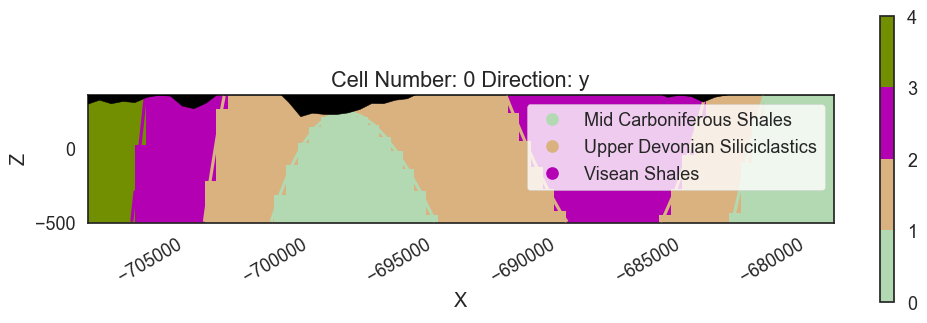

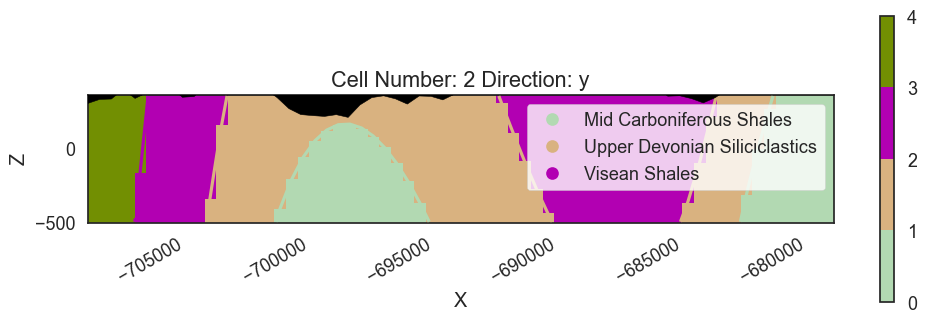

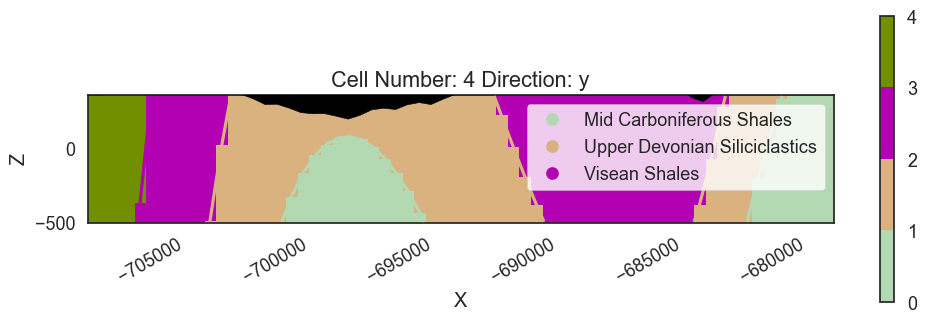

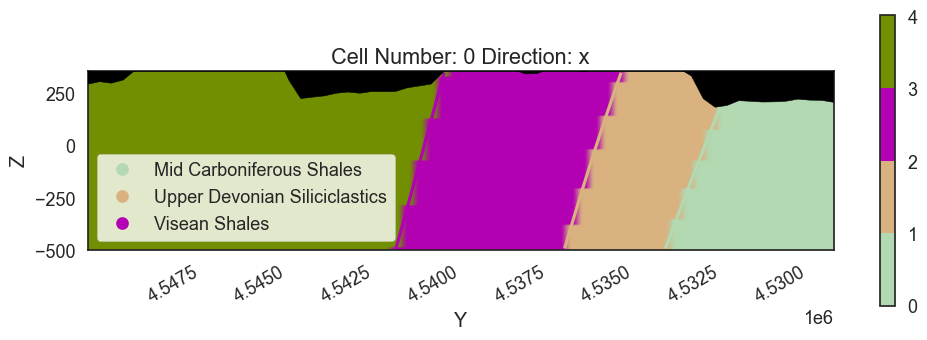

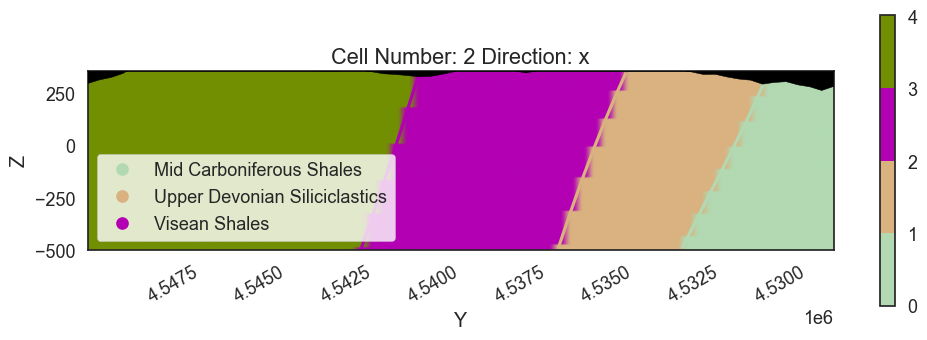

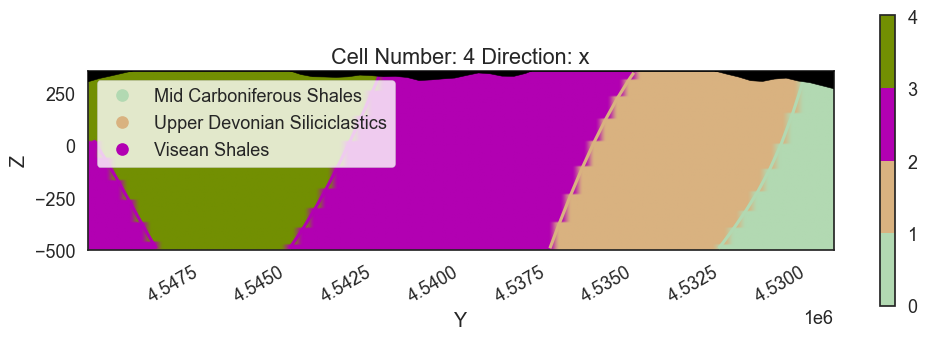

In [ ]:
# Create cross sections if enabled
if trigger_create_cross_section:
    print("Creating cross section...")
    HelperMethods.create_cross_section(geo_model, cross_section=5)
    print("Cross section created!")
else:
    print("Cross section creation is disabled")

## 11. Visualise Geological Model from Above

c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_sections_api.py:106: UserWarning: Section contacts not implemented yet. We need to pass scalar field for the sections grid
  warnings.warn(
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


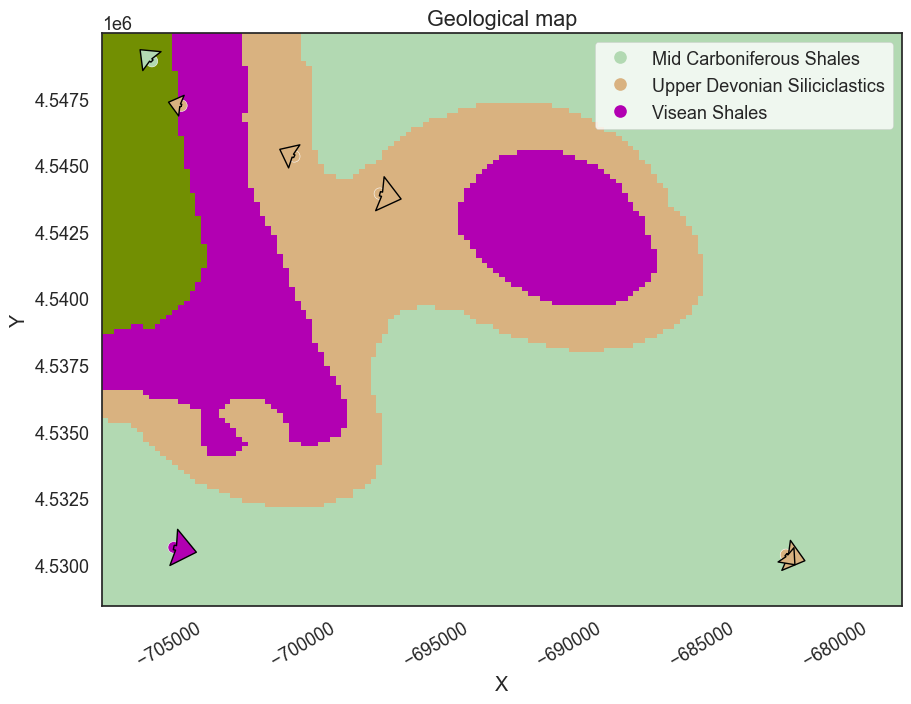

In [15]:
ret = gpv.plot_2d(
    geo_model,
    direction="z",
    section_names=['topography'],
    # show_topography=True,
    show_lith=True,
    show_boundaries=True,
    show_data=True,
    legend=True
)

fig = plt.gcf()
ax = plt.gca()
ax.invert_yaxis()
plt.show()

# 12. Import QGIS Data

In [16]:
import geopandas as gpd

# Load the QGIS geology data
gdf = gpd.read_file(r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\clippedGeologyEn3.gpkg")
path_to_data = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\formationinputpoints.csv"
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')

path_to_orientations = r"C:\Users\mrcon\OneDrive\Data B\School\GP2\Internship\Mineye\GIS\Tharsis\Output\orientations.csv"
orientations_df = pd.read_csv(path_to_orientations, encoding='latin1', engine='python')

gdf['GEOLOGY'] = gdf['GEOLOGY'].replace('Purple to multicolored shales and mudstones with radiolarian-rich beds – Purple shales','Visean Shales')

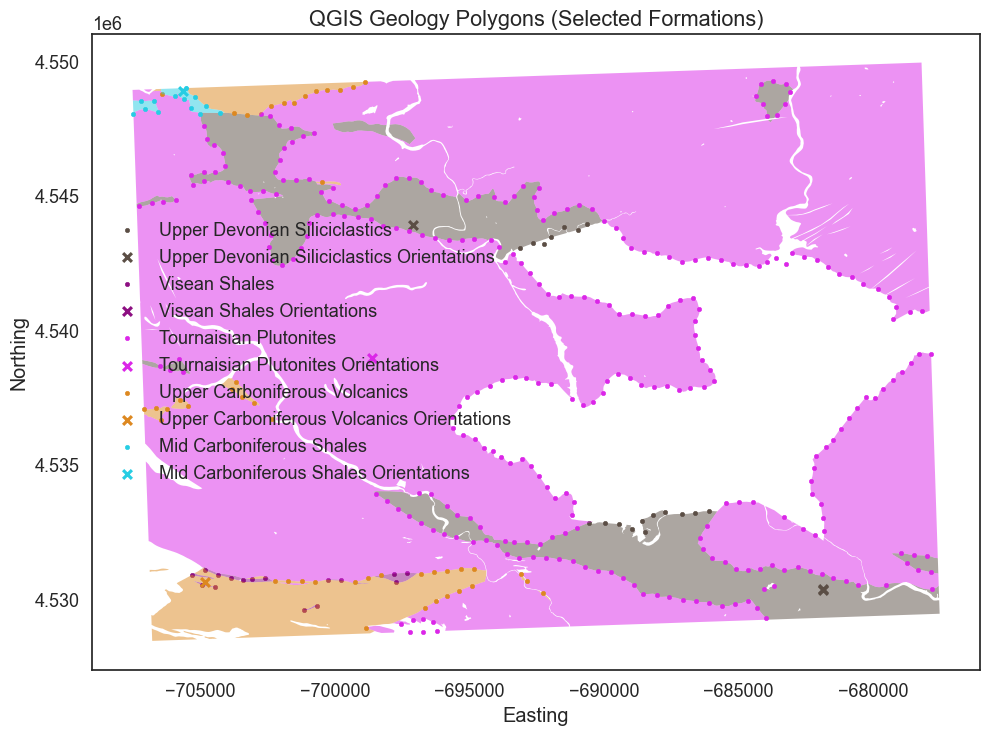

In [ ]:
formations = [
    'Upper Devonian Siliciclastics',
    'Visean Shales',
    'Tournaisian Plutonites',
    'Upper Carboniferous Volcanics',
    'Mid Carboniferous Shales'
]
colors = ["#5B4E45", "#8D0F82FF","#DB26E8", "#DD8820", "#26CDE3"]

fig, ax = plt.subplots(figsize=(10, 10))
for formation, colour in zip(formations, colors):
    gdf[gdf['GEOLOGY'] == formation].plot(ax=ax, color=colour, alpha=0.5)
    ax.scatter(points_df[points_df['formation'] == formation]['X'], points_df[points_df['formation'] == formation]['Y'], color=colour, s=10, label=formation)
    ax.scatter(orientations_df[orientations_df['formation'] == formation]['X'], orientations_df[orientations_df['formation'] == formation]['Y'], color=colour, s=40, marker='x', label=f"{formation} Orientations")
    
# plt.close(fig)
ax.set_title('QGIS Geology Polygons (All Formations)')
ax.set_xlabel('Easting')
ax.set_ylabel('Northing')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

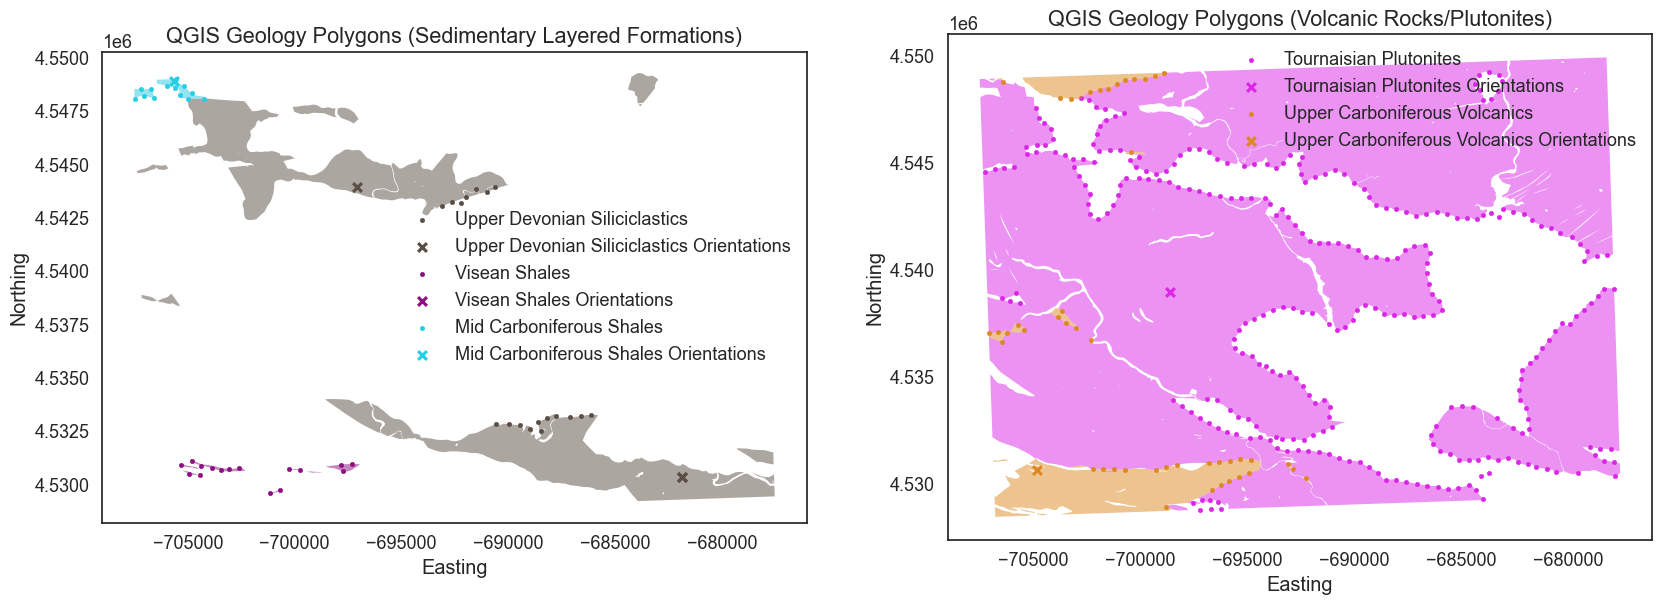

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Sedimentary Layered Formations
formations1 = [
    'Upper Devonian Siliciclastics',
    'Visean Shales',
    'Mid Carboniferous Shales'
]
colors1 = ["#5B4E45", "#8D0F82FF", "#26CDE3"]

for formation, colour in zip(formations1, colors1):
    gdf[gdf['GEOLOGY'] == formation].plot(ax=axes[0], color=colour, alpha=0.5)
    axes[0].scatter(points_df[points_df['formation'] == formation]['X'], points_df[points_df['formation'] == formation]['Y'], color=colour, s=10, label=formation)
    axes[0].scatter(orientations_df[orientations_df['formation'] == formation]['X'], orientations_df[orientations_df['formation'] == formation]['Y'], color=colour, s=40, marker='x', label=f"{formation} Orientations")

axes[0].set_title('QGIS Geology Polygons (Sedimentary Layered Formations)')
axes[0].set_xlabel('Easting')
axes[0].set_ylabel('Northing')
axes[0].set_aspect('equal')
axes[0].legend()
axes[0].grid(False)

# Volcanic Rocks/Plutonites
formations2 = [
    'Tournaisian Plutonites',
    'Upper Carboniferous Volcanics',
]
colors2 = ["#DB26E8", "#DD8820"]

for formation, colour in zip(formations2, colors2):
    gdf[gdf['GEOLOGY'] == formation].plot(ax=axes[1], color=colour, alpha=0.5)
    axes[1].scatter(points_df[points_df['formation'] == formation]['X'], points_df[points_df['formation'] == formation]['Y'], color=colour, s=10, label=formation)
    axes[1].scatter(orientations_df[orientations_df['formation'] == formation]['X'], orientations_df[orientations_df['formation'] == formation]['Y'], color=colour, s=40, marker='x', label=f"{formation} Orientations")

axes[1].set_title('QGIS Geology Polygons (Volcanic Rocks/Plutonites)')
axes[1].set_xlabel('Easting')
axes[1].set_ylabel('Northing')
axes[1].set_aspect('equal')
axes[1].legend()
axes[1].grid(False)

# 13. Validating Gempy values with QGIS values

Assess the whole domain

In [18]:
# lithology in every voxel
lith_block = geo_model.solutions.raw_arrays.lith_block
lith_block_reshaped = lith_block.reshape(64,64,64)

# coordinate of every voxel
voxel_coords = geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)

In [19]:
voxel_coords_reshaped[:,:,-1,:2].reshape(64*64,2)

array([[-707287.59375 , 4549779.078125],
       [-707287.59375 , 4549443.234375],
       [-707287.59375 , 4549107.390625],
       ...,
       [-677752.40625 , 4529292.609375],
       [-677752.40625 , 4528956.765625],
       [-677752.40625 , 4528620.921875]])

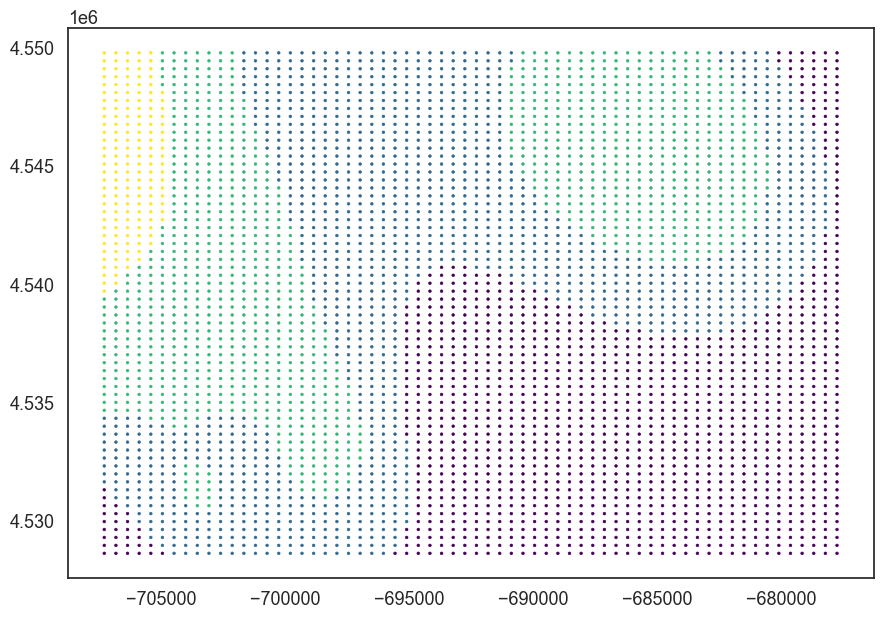

In [20]:
x_voxel = []
y_voxel = []

for i in range(64*64):
    x_voxel.append(voxel_coords_reshaped[:,:,-1,:2].reshape(64*64,2)[i][0])

for i in range(64*64):
    y_voxel.append(voxel_coords_reshaped[:,:,-1,:2].reshape(64*64,2)[i][1])

plt.scatter(x_voxel, y_voxel, c=lith_block_reshaped[:,:,-1].flatten(), cmap='viridis', s=4)

In [24]:
# Extract coordinates and geology from the GeoDataFrame
coordinates = []
geology_values = []

for idx, row in gdf.iterrows():
    geometry = row.geometry
    geology = row['GEOLOGY']
    
    if geometry.geom_type == 'Polygon':
        # Get exterior coordinates of the polygon
        coords = list(geometry.exterior.coords)
        for coord in coords:
            coordinates.append([coord[0], coord[1]])
            geology_values.append(geology)
    elif geometry.geom_type == 'MultiPolygon':
        # Handle MultiPolygon geometries
        for poly in geometry.geoms:
            coords = list(poly.exterior.coords)
            for coord in coords:
                coordinates.append([coord[0], coord[1]])
                geology_values.append(geology)

# Convert to numpy arrays
coordinates = np.array(coordinates)
geology_values = np.array(geology_values)

print(f"Extracted {len(coordinates)} coordinate points")
print(f"Unique geology types: {np.unique(geology_values)}")
print(f"Coordinates shape: {coordinates.shape}")

Extracted 20285 coordinate points
Unique geology types: ['Alternating shales, siltstones, metasedimentary sandstones and quartzites'
 'Mid Carboniferous Shales' 'Mid Devonian Siliciclastics'
 'Tournaisian Plutonites' 'Upper Carboniferous Volcanics'
 'Upper Devonian Siliciclastics' 'Visean Shales']
Coordinates shape: (20285, 2)


In [25]:
from scipy.spatial import cKDTree


# coordinates: (n_points, 2) array from gdf (X, Y)
# voxel_coords_reshaped: (64, 64, 64, 3) array (Z, Y, X, [X, Y, Z])
# lith_block_reshaped: (64, 64, 64) array (Z, Y, X)

# We'll use the top layer (surface) for each (i, j) in the grid
surface_z = 63  # top voxel index

# Prepare the KDTree with voxel surface coordinates
surface_z = 63  # top voxel index
voxel_surface_coords = voxel_coords_reshaped[:, :, surface_z, :2].reshape(-1, 2)  # shape: (4096, 2)
tree = cKDTree(voxel_surface_coords)

# Query the nearest voxel for each QGIS coordinate
distances, indices = tree.query(coordinates)

# Map flat indices back to (i, j) indices
ij_indices = np.unravel_index(indices, (64, 64))

# Get lithology for each matched voxel
matched_lithologies = lith_block_reshaped[ij_indices[0], ij_indices[1], surface_z]

print("Lithology codes for QGIS coordinates:", matched_lithologies)

Lithology codes for QGIS coordinates: [2 2 2 ... 2 2 2]


In [26]:
# compare matched_lithologies to geology_values
dictionary = {
    1: 'Mid Carboniferous Shales',
    2: 'Upper Devonian Siliciclastics',
    3: 'Visean Shales',
    4: 'Basement',
}

# translate lithology id to string
matched_lithologies_strings = [dictionary[int(val)] for val in matched_lithologies]

# Count True and False values in the comparison
comparison = matched_lithologies_strings == geology_values
true_count = np.sum(comparison)
false_count = len(comparison) - true_count

print(f"True matches: {true_count}")
print(f"False matches: {false_count}")
print(f"Total comparisons: {len(comparison)}")
print(f"Accuracy: {true_count/len(comparison)*100:.2f}%")

True matches: 1578
False matches: 18707
Total comparisons: 20285
Accuracy: 7.78%


Assess individual data points

In [27]:
calculated_lith_values_at_coords: np.ndarray = gp.compute_model_at(
    gempy_model=geo_model,
    at=points_df[['X', 'Y', 'Z']].values
)


dictionary = {
    1: 'Mid Carboniferous Shales',
    2: 'Upper Devonian Siliciclastics',
    3: 'Visean Shales',
    4: 'Basement',
}

# translate lithology id to string
calculated_lith_strings = [dictionary[int(val)] for val in calculated_lith_values_at_coords]

actual_lith_values_at_coords = points_df['formation'].values


# Count True and False values in the comparison
comparison = calculated_lith_strings == actual_lith_values_at_coords
true_count = np.sum(comparison)
false_count = len(comparison) - true_count

print(f"True matches: {true_count}")
print(f"False matches: {false_count}")
print(f"Total comparisons: {len(comparison)}")
print(f"Accuracy: {true_count/len(comparison)*100:.2f}%")

Active grids: GridTypes.NONE|CUSTOM
Setting Backend To: AvailableBackends.numpy


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 9 chunks
Chunking done: 8 chunks
True matches: 14
False matches: 374
Total comparisons: 388
Accuracy: 3.61%


# Visual comparison

In [28]:
from scipy.spatial import cKDTree

# lithology in every voxel
lith_block = geo_model.solutions.raw_arrays.lith_block
lith_block_reshaped = lith_block.reshape(64,64,64)

# coordinate of every voxel
voxel_coords = geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)

top_lithology = lith_block_reshaped[:, :, surface_z]
top_coordinates = voxel_coords_reshaped[:, :, surface_z]




# look for nearest QGIS point for each voxel coordinate

# Get the top layer coordinates in the format (X, Y)
top_coords_xy = top_coordinates[:, :, :2].reshape(-1, 2)  # Reshape to (4096, 2)




formations = [
    'Upper Devonian Siliciclastics',
    'Visean Shales',
    'Tournaisian Plutonites',
    'Upper Carboniferous Volcanics',
    'Mid Carboniferous Shales'
]

# Filter coordinates and geology_values to only include specified formations
mask = np.isin(geology_values, formations)

qgis_coords = coordinates  # Already in (X, Y) format
qgis_coords_filtered = qgis_coords[mask]
filtered_geology_values = geology_values[mask]

# Create KDTree with QGIS coordinates
tree = cKDTree(qgis_coords_filtered)

# Find nearest QGIS point for each voxel coordinate
distances, indices = tree.query(top_coords_xy)

# Get corresponding geology values
nearest_geology = filtered_geology_values[indices]

# Translate geology string to id
geology_to_id = {name: idx for idx, name in enumerate(formations)}
nearest_geology_ids = np.array([geology_to_id[g] for g in nearest_geology.flatten() if g in geology_to_id]).reshape(64, 64)

# Reshape back to grid format
nearest_geology_grid = nearest_geology.reshape(64, 64)

# Visualize the nearest QGIS geology for each voxel
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(top_lithology, cmap='viridis', interpolation='nearest')
plt.colorbar(label='GemPy Lithology ID', ticks=[1,2,3,4])
plt.title('GemPy Top Layer Lithology')
plt.xlabel('X Index')
plt.ylabel('Y Index')

plt.subplot(1, 2, 2)
# Create a mapping for geology to numbers for visualization
unique_geologies = np.unique(nearest_geology)

plt.imshow(nearest_geology_ids, cmap='viridis', interpolation='nearest')
plt.colorbar(label='QGIS Lithology ID', ticks=[1,2,3,4])
plt.title('Nearest QGIS Geology')
plt.xlabel('X Index')
plt.ylabel('Y Index')

plt.tight_layout()
plt.show()

print(f"Unique QGIS geologies found: {unique_geologies}")
print(f"Average distance to nearest QGIS point: {np.mean(distances):.2f} meters")

# Calculate similarity
similarity = np.sum(nearest_geology_ids == top_lithology) / np.prod(top_lithology.shape) * 100 # number of voxels same / 64*64
print(f"Similarity between GemPy and QGIS lithology: {similarity:.2f}%")

ValueError: cannot reshape array of size 0 into shape (64,64,64)

# 14. Geophysical data

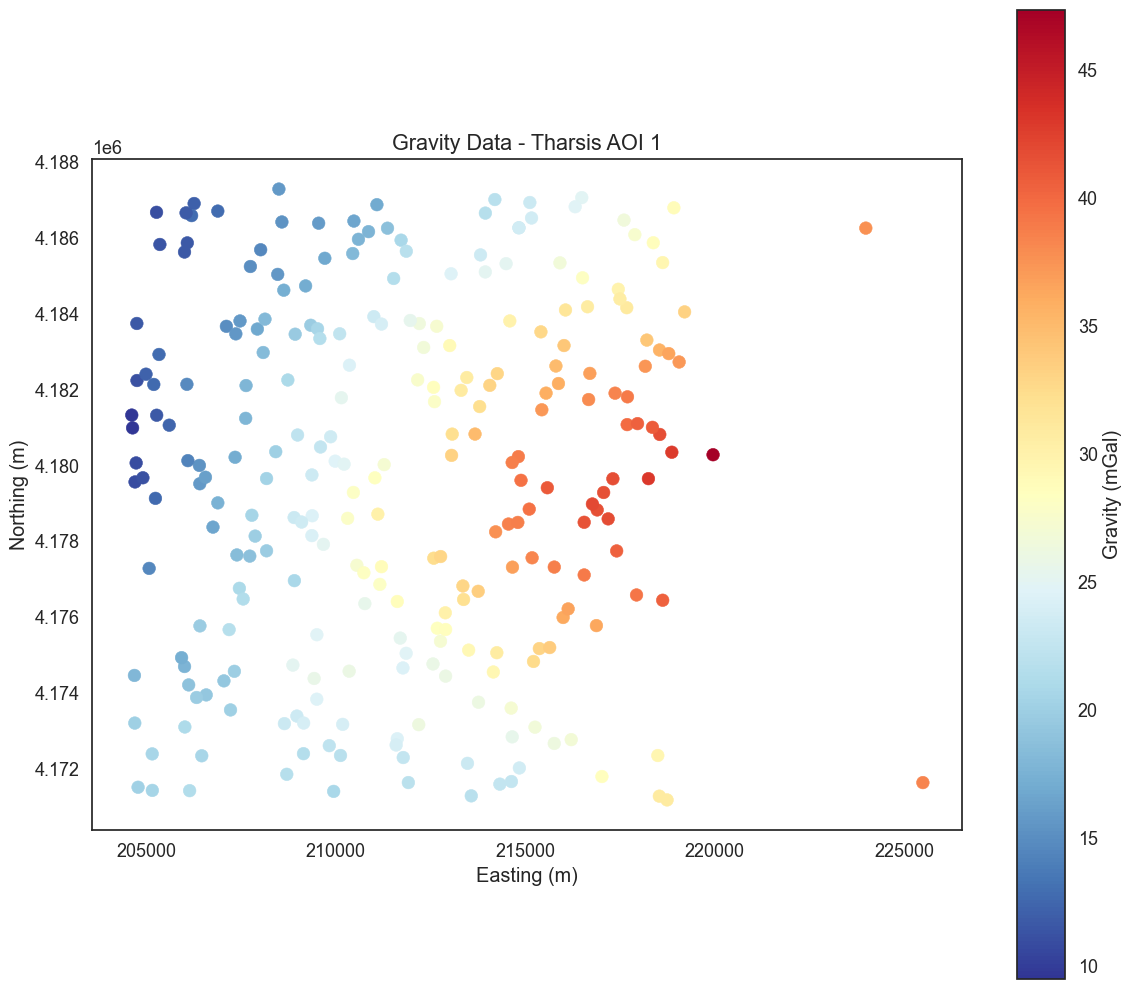

Gravity data loaded successfully!
Data shape: (260, 8)
Columns: ['ID', 'VALU_COORX', 'VALU_COORY', 'CODE_H50', 'CODE_DOCU', 'VALU_BOU267', 'ESRI_OID', 'geometry']
Gravity range: 9.51 to 47.32 mGal


In [29]:
# Load and plot the geophysical gravity data
gravity_data = gpd.read_file(r"C:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\Data\Tharsis AOI 1\AOI1_GF_Gravity_cropped_EPSG23030.geojson")


# Create a plot of the gravity data
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the gravity data with a colormap
gravity_plot = gravity_data.plot(
    column='VALU_BOU267', 
    ax=ax, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Gravity (mGal)', 'orientation': 'vertical'}
)

ax.set_title('Gravity Data - Tharsis AOI 1')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Gravity data loaded successfully!")
print(f"Data shape: {gravity_data.shape}")
print(f"Columns: {gravity_data.columns.tolist()}")
print(f"Gravity range: {gravity_data['VALU_BOU267'].min():.2f} to {gravity_data['VALU_BOU267'].max():.2f} mGal")

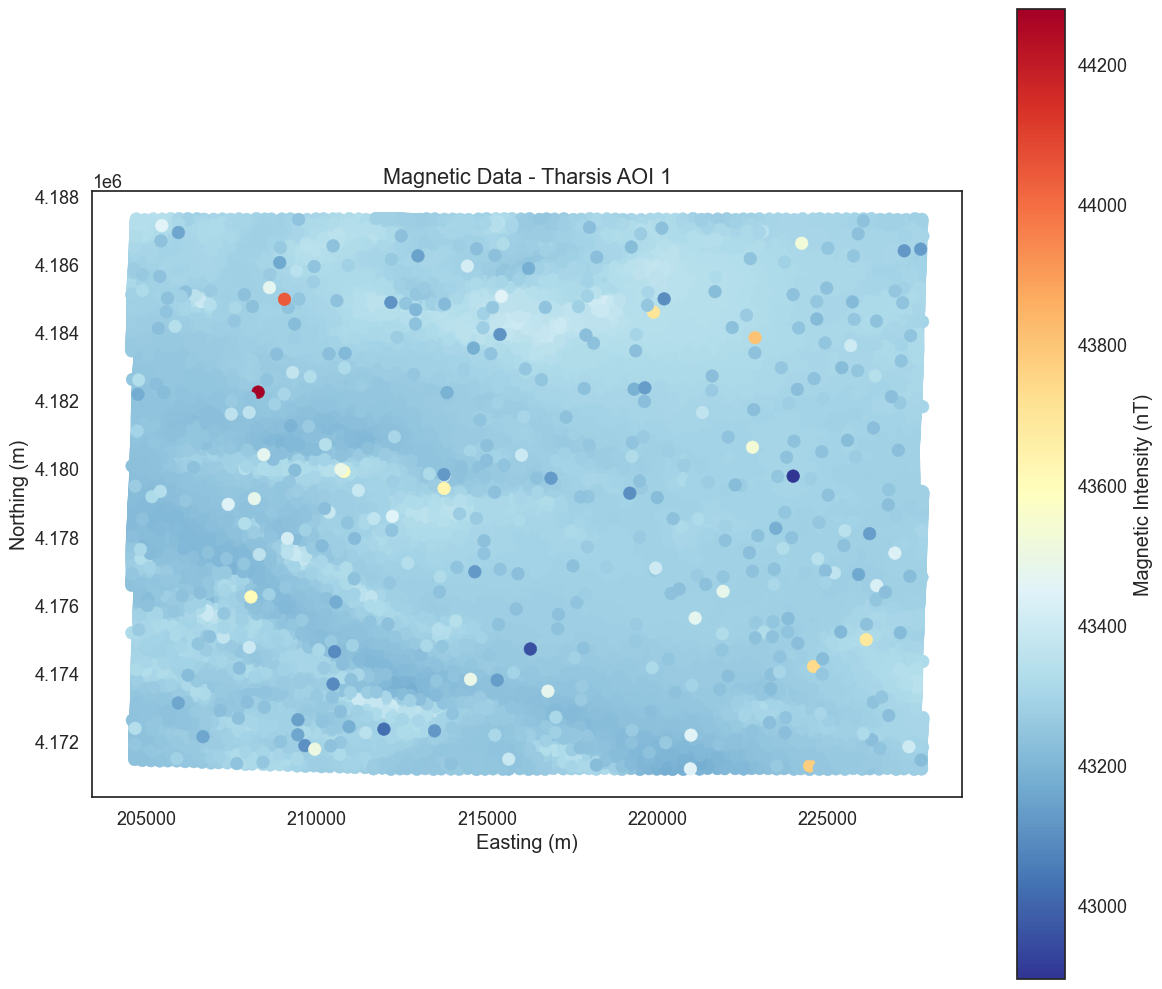

Magnetic data loaded successfully!
Data shape: (54261, 16)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry']
Magnetic range: 42894.50 to 44278.60 nT


In [30]:
# Load and plot the geophysical gravity data
magnetic_data = gpd.read_file(r"C:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\Data\Tharsis AOI 1\AOI1_airborneMagnetics_EPSG23030.geojson")


# Create a plot of the gravity data
fig, ax = plt.subplots(figsize=(12, 10))


# Plot the gravity data with a colormap
magnetic_plot = magnetic_data.plot(
    column='MAG', 
    ax=ax, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax.set_title('Magnetic Data - Tharsis AOI 1')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {magnetic_data.shape}")
print(f"Columns: {magnetic_data.columns.tolist()}")
print(f"Magnetic range: {magnetic_data['MAG'].min():.2f} to {magnetic_data['MAG'].max():.2f} nT")

1 voxel:

* 1 lithology: scalar
* 3 coordinates: floats
* 2 geophysical values: floats

# 15. Filtering and Sampling Geophysical Data

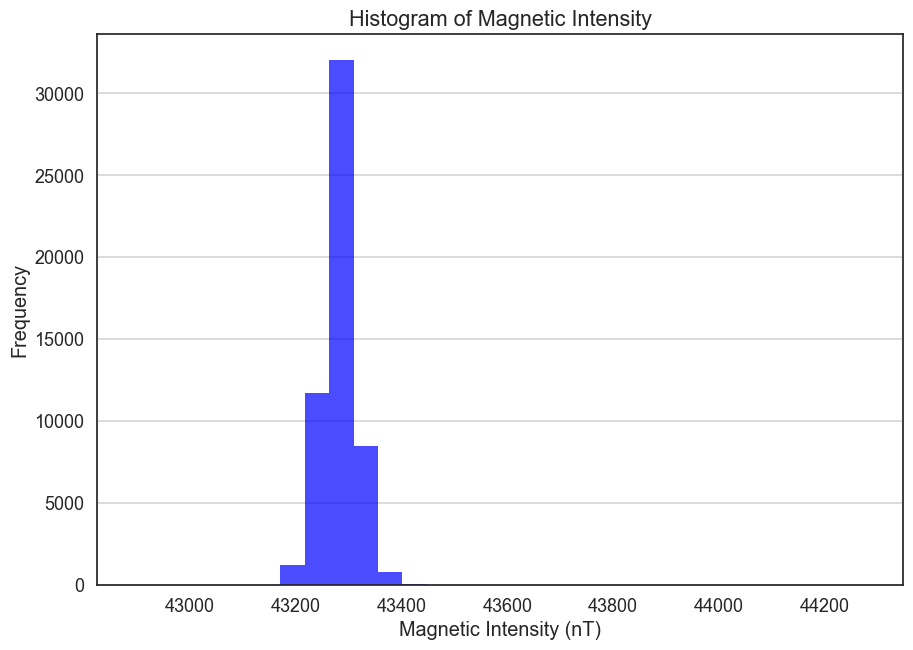

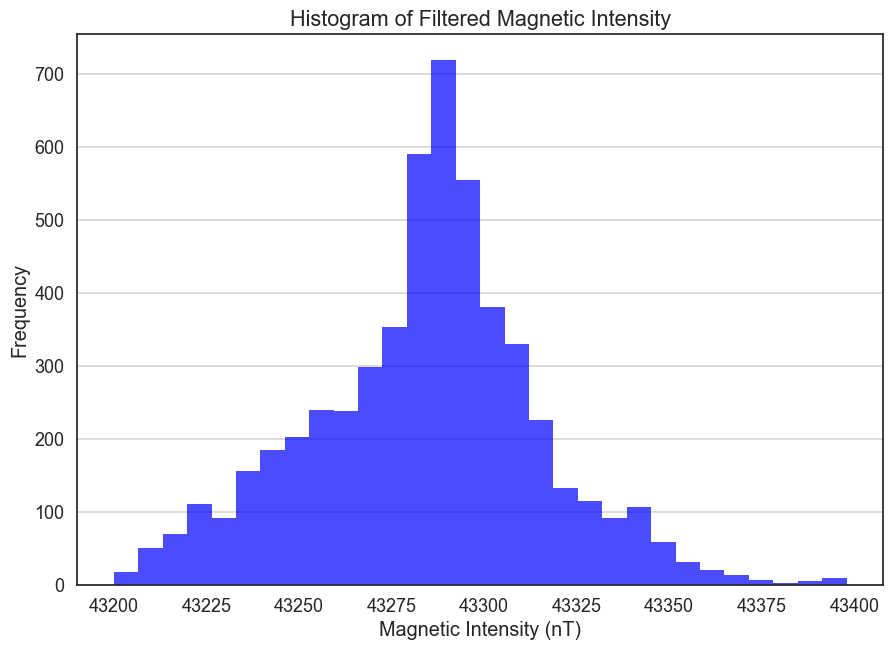

In [31]:
plt.hist(magnetic_data['MAG'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Magnetic Intensity')
plt.xlabel('Magnetic Intensity (nT)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# remove outliers below 43200 and 43400
# Sample the magnetic data (e.g., every 10th point)
sampled_magnetic = magnetic_data.iloc[::10].copy()

filtered_magnetic = sampled_magnetic[
    (sampled_magnetic['MAG'] >= 43200) &
    (sampled_magnetic['MAG'] <= 43400)
].copy()

plt.hist(filtered_magnetic['MAG'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Filtered Magnetic Intensity')
plt.xlabel('Magnetic Intensity (nT)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

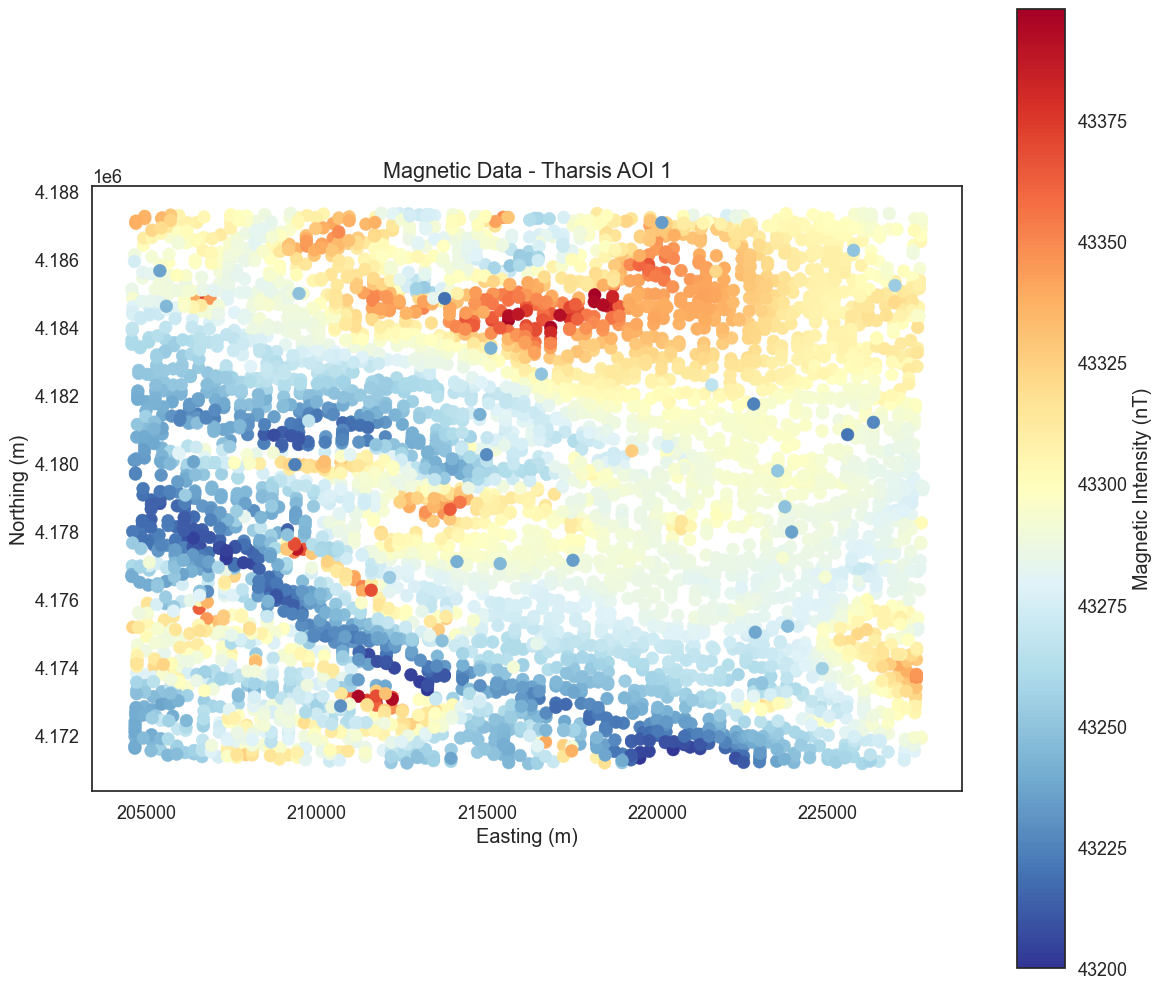

Magnetic data loaded successfully!
Data shape: (5404, 16)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry']
Magnetic range: 43200.00 to 43397.90 nT


In [32]:
# Create a plot of the gravity data
fig, ax = plt.subplots(figsize=(12, 10))


# Plot the gravity data with a colormap
filtered_magnetic_plot = filtered_magnetic.plot(
    column='MAG', 
    ax=ax, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax.set_title('Magnetic Data - Tharsis AOI 1')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {filtered_magnetic.shape}")
print(f"Columns: {filtered_magnetic.columns.tolist()}")
print(f"Magnetic range: {filtered_magnetic['MAG'].min():.2f} to {filtered_magnetic['MAG'].max():.2f} nT")

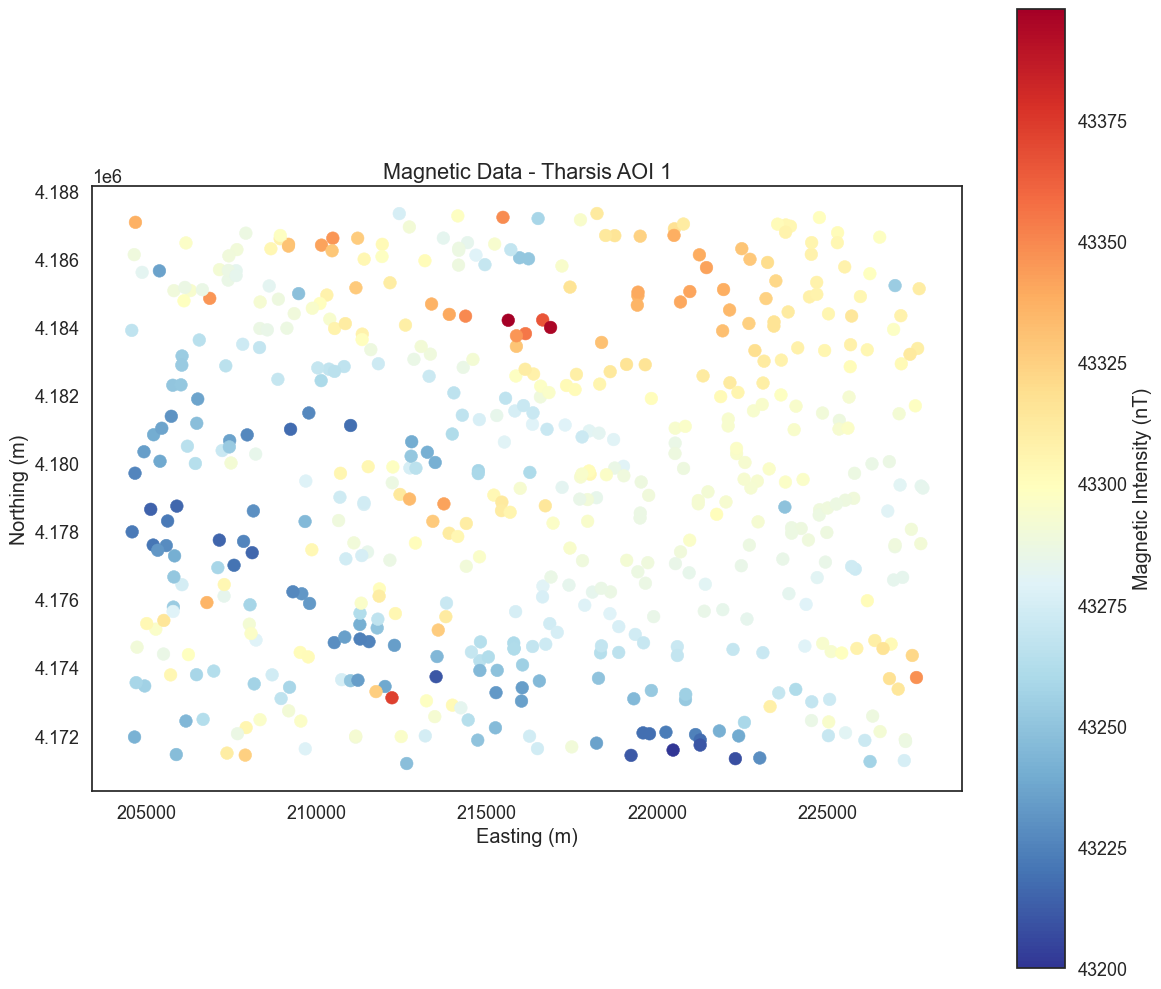

Magnetic data loaded successfully!
Data shape: (541, 16)
Columns: ['ID', 'IDTR', 'VUELO', 'LINEA', 'XLON', 'YLAT', 'MAG', 'POT', 'THO', 'URA', 'TOT', 'RAD', 'BAR', 'GPS', 'FECHA', 'geometry']
Magnetic range: 43200.00 to 43397.90 nT


In [33]:
# sample the magnetic data
filtered_magnetic_sampled = filtered_magnetic[::10]

# Create a plot of the gravity data
fig, ax = plt.subplots(figsize=(12, 10))


# Plot the gravity data with a colormap
filtered_magnetic_sampled_plot = filtered_magnetic_sampled.plot(
    column='MAG', 
    ax=ax, 
    cmap='RdYlBu_r', 
    legend=True,
    legend_kwds={'label': 'Magnetic Intensity (nT)', 'orientation': 'vertical'}
)

ax.set_title('Magnetic Data - Tharsis AOI 1')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Magnetic data loaded successfully!")
print(f"Data shape: {filtered_magnetic_sampled.shape}")
print(f"Columns: {filtered_magnetic_sampled.columns.tolist()}")
print(f"Magnetic range: {filtered_magnetic_sampled['MAG'].min():.2f} to {filtered_magnetic_sampled['MAG'].max():.2f} nT")

Sampled data extracted successfully!
Sampled formation points shape: (19, 5)
Sampled orientations shape: (4, 8)


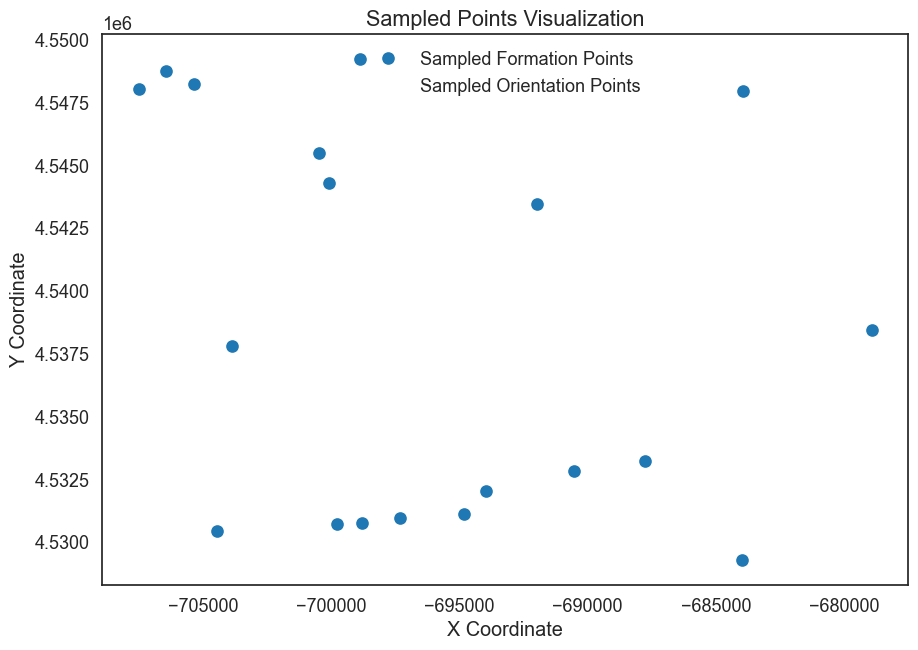

In [79]:

# Extract the sampled data files into dataframes
sampled_points_df = pd.read_csv("sampled_formationinputpoints.csv", encoding='latin1', engine='python')
sampled_orientations_df = pd.read_csv("sampled_orientationinputpoints.csv", encoding='latin1', engine='python')

print("Sampled data extracted successfully!")
print(f"Sampled formation points shape: {sampled_points_df.shape}")
print(f"Sampled orientations shape: {sampled_orientations_df.shape}")

plt.plot(sampled_points_df['X'], sampled_points_df['Y'], 'o', label='Sampled Formation Points')
plt.plot(sampled_orientations_df['X'], sampled_orientations_df['Y'], 'x', label='Sampled Orientation Points')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Sampled Points Visualization')
plt.legend()
plt.show()

Could not find element 'Mid Carboniferous_Shales' in any group.
Could not find element 'Visean_Shales' in any group.
Could not find element 'Upper_Devonian_Siliciclastics' in any group.
Could not find element 'Tournaisian_Plutonites' in any group.
Could not find element 'Upper_Carboniferous_Volcanics' in any group.
Available elements: ['Mid Carboniferous Shales', 'Tournaisian Plutonites', 'Upper Carboniferous Volcanics', 'Upper Devonian Siliciclastics', 'Visean Shales', 'basement']
Tournaisian_Plutonites element not found, skipping plutons group
Upper_Carboniferous_Volcanics element not found, skipping volcanics group
Setting Backend To: AvailableBackends.numpy


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 19 chunks
Chunking done: 14 chunks
Setting topography...
Active grids: GridTypes.NONE|TOPOGRAPHY|OCTREE
Computing geological model... (this may take a while)
Setting Backend To: AvailableBackends.numpy


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 19 chunks
Chunking done: 14 chunks
Model computation completed successfully!
Creating cross section...


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Cross section created!


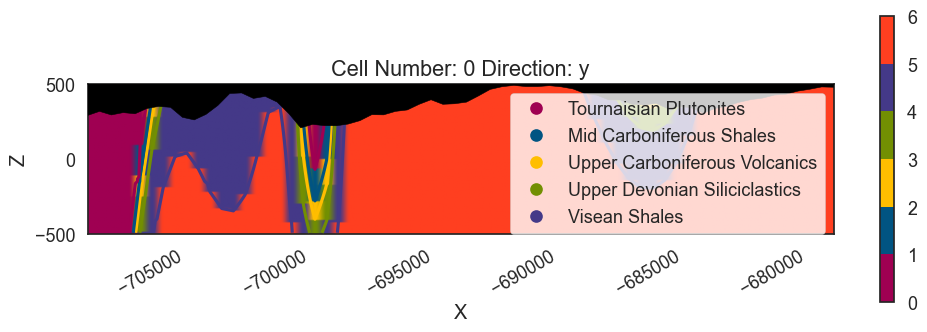

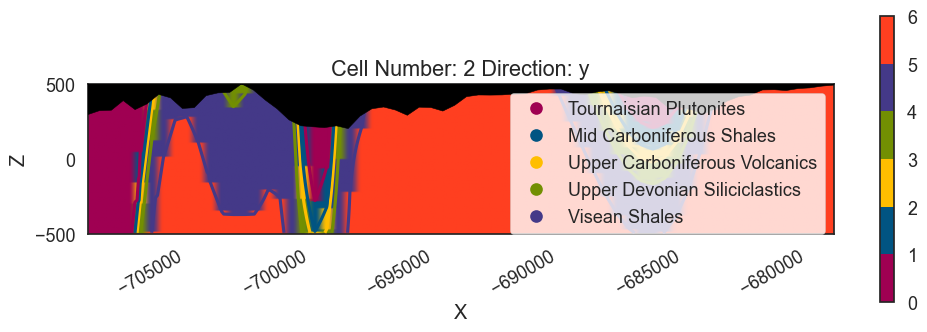

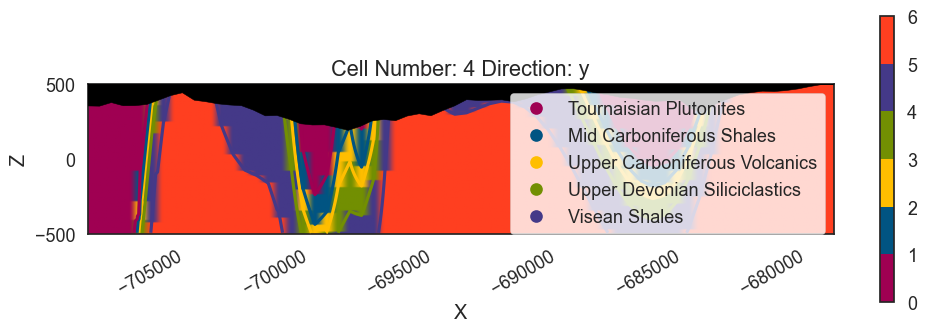

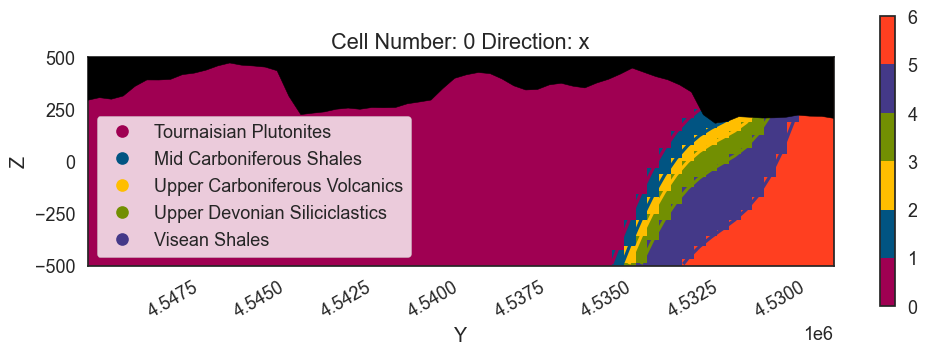

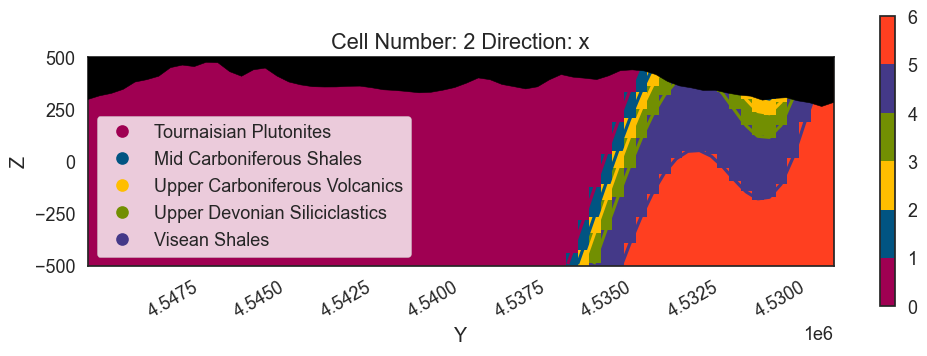

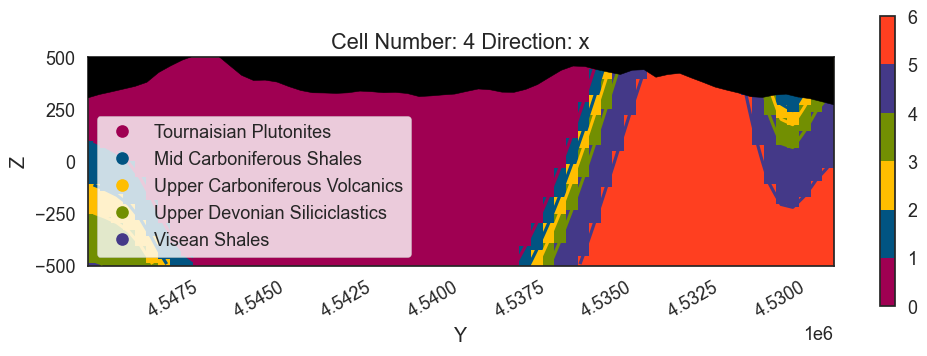

In [88]:
import gempy as gp
import gempy_engine
import os

# 1. Initialize model
top_right = (-678192, 4549947)
bottom_right = (-677518, 4529455)
bottom_left = (-706792, 4528453)
top_left = (-707522, 4548927)

# Calculate bounding box of the area of interest
min_x = min(top_left[0], bottom_left[0])
max_x = max(top_right[0], bottom_right[0])
min_y = min(bottom_left[1], bottom_right[1])
max_y = max(top_left[1], top_right[1])
max_z = points_df['Z'].max()
nx = ny = nz = 64  # Define grid resolution

geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
    refinement=6,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=os.path.join(BASE_DIR, "sampled_orientationinputpoints2.csv"),
        path_to_surface_points=os.path.join(BASE_DIR, "sampled_formationinputpoints.csv"),
    )
)

# 3. Define units (surfaces) and assign to series
# Update the structural frame to include all formations from the data
gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        # "Strat_Series": ["Upper_Devonian_Siliciclastics", "Visean_Shales", "Mid_Carboniferous_Shales"],
        "Strat_Series": ["Mid Carboniferous_Shales", "Visean_Shales", "Upper_Devonian_Siliciclastics"],
        "Tournaisian_Plutonites_S": ["Tournaisian_Plutonites"],
        "Upper_Carboniferous_Volcanics_S": ["Upper_Carboniferous_Volcanics"]
    }
)

# Check available elements in structural frame
print("Available elements:", [element.name for element in geo_model.structural_frame.structural_elements])

# Plutons (intrusive blobs) - only add if element exists
try:
    pluton_element = geo_model.structural_frame.get_element_by_name("Tournaisian_Plutonites")
    gp.add_structural_group(
        model=geo_model,
        group_index=4,
        structural_group_name="Tournaisian_Plutonites_S",
        elements=[pluton_element],
        structural_relation=gp.data.StackRelationType.ERODE
    )
    print("Added plutons structural group")
except:
    print("Tournaisian_Plutonites element not found, skipping plutons group")

# Volcanics (surface lava flows) - only add if element exists
try:
    volcanic_element = geo_model.structural_frame.get_element_by_name("Upper_Carboniferous_Volcanics")
    gp.add_structural_group(
        model=geo_model,
        group_index=5,
        structural_group_name="Upper_Carboniferous_Volcanics_S",
        elements=[volcanic_element],
        structural_relation=gp.data.StackRelationType.ONLAP
    )
    print("Added volcanics structural group")
except:
    print("Upper_Carboniferous_Volcanics element not found, skipping volcanics group")



# # 5. Compute model
# gp.compute_model(geo_model)

# 6. Visualization
import gempy_viewer as gpv

# Set topography from processed file
print("Setting topography...")
gp.set_topography_from_file(grid=geo_model.grid, filepath=path_to_topography_reduced)

# Compute the geological model
print("Computing geological model... (this may take a while)")
gempy_model = gp.compute_model(geo_model)

print("Model computation completed successfully!")

# Create cross sections if enabled
threading.Thread(target=HelperMethods.plot_3d_async, args=(geo_model,)).start()
if trigger_create_cross_section:
    print("Creating cross section...")
    HelperMethods.create_cross_section(geo_model, cross_section=5)
    print("Cross section created!")
else:
    print("Cross section creation is disabled")

